Libraries Imported Successfully

Dataset Loaded Successfully

Dataset Shape:
(298837, 10)

Sample Dataset Shape:
(20000, 10)

Preprocessing Function Imported Successfully

Dataset Columns:
['id', 'title', 'user_id', 'profilename', 'review_time', 'review_text', 'review_length', 'combined_text', 'review_datetime', 'review_year']

Null Values Handled Successfully

================ ORIGINAL TEXT ================

The Lies of Locke Lamora Scott Lynch along with Patrick Rothfuss (The Name of the Wind) will rock your world!!! two of the greatest first novels from two of the greatest promises in the literal fantasy world. Ok, it sounds like "too much" indeed, but after you read "The Lies of Locke Lamora" perhaps you will understand the great feeling that a great book leaves in you. You will be transported to a different and raw world. A world where you better be alert or you could probably loose all of your money or worst, your life.Scott Lynch has created an incredible world of MAFIA, assasin

100%|██████████| 20000/20000 [00:08<00:00, 2344.97it/s]


Text Cleaning Completed Successfully


,combined_text,cleaned_text
287573,The Lies of Locke Lamora Scott Lynch along wit...,lies locke lamora scott lynch along patrick ro...
28692,Great Expectations (Signet classics) This is m...,great expectations signet classics least favor...
219931,The Power of Kabbalah: Technology for the Soul...,power kabbalah technology soul ive noticed man...
102912,Language Teaching Awareness: A Guide to Explor...,language teaching awareness guide exploring be...
124804,Las Luces de Septiembre (Spanish Edition) I bo...,las luces septiembre spanish edition bought on...



Empty Cleaned Reviews: 0

Dataset Shape After Removing Empty Reviews:
(20000, 11)

Cleaned Length Feature Created

Cleaned Text Length Statistics:


count    20000.000000
mean       557.578300
std        629.916801
min         11.000000
25%        192.000000
50%        353.000000
75%        667.250000
max      11224.000000
Name: cleaned_length, dtype: float64

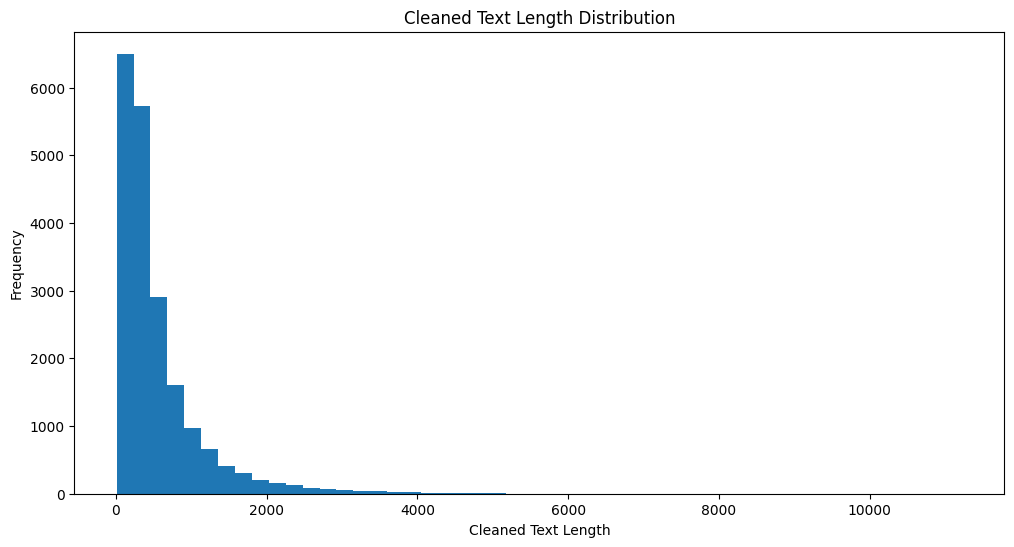

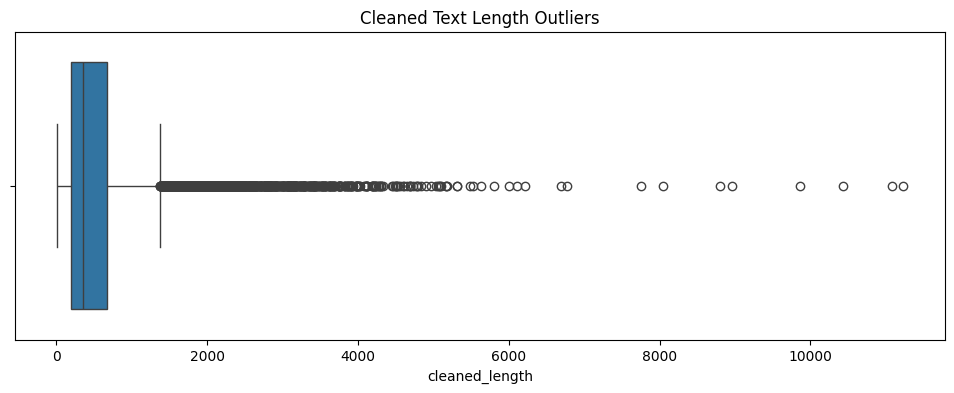


Duplicate Cleaned Reviews: 51

Dataset Shape After Removing Duplicates:
(19949, 12)

Top 20 Cleaned Words:
[('book', 37593), ('read', 14792), ('one', 12046), ('story', 8009), ('like', 7612), ('would', 6740), ('books', 6460), ('great', 6098), ('time', 6065), ('good', 5730), ('life', 5553), ('reading', 5182), ('first', 5117), ('many', 5054), ('much', 4875), ('also', 4771), ('people', 4647), ('well', 4493), ('novel', 4391), ('really', 4366)]


,Word,Frequency
0,book,37593
1,read,14792
2,one,12046
3,story,8009
4,like,7612
5,would,6740
6,books,6460
7,great,6098
8,time,6065
9,good,5730


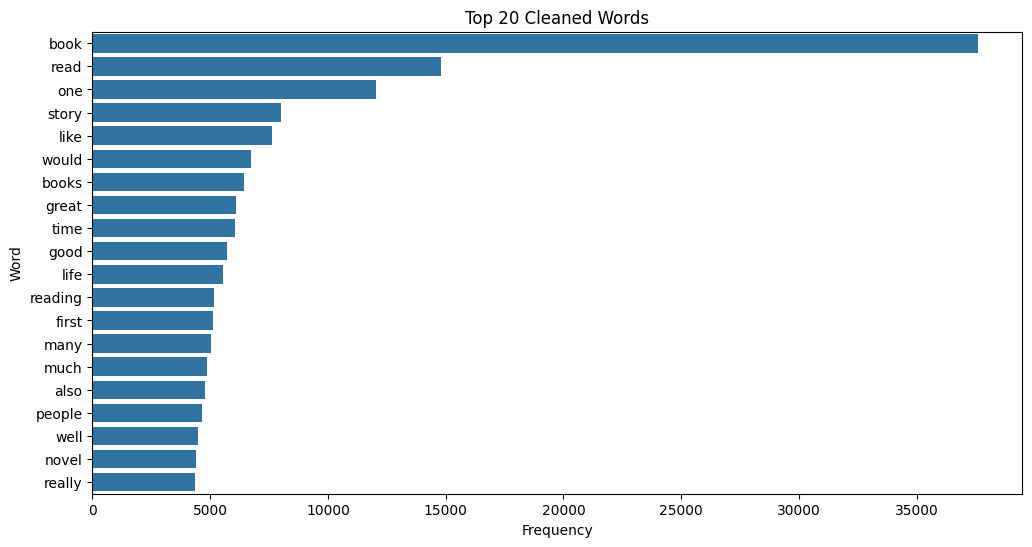


Word Count Feature Created

Word Count Statistics:


count    19949.000000
mean        76.519274
std         83.482796
min          2.000000
25%         27.000000
50%         50.000000
75%         92.000000
max       1479.000000
Name: word_count, dtype: float64

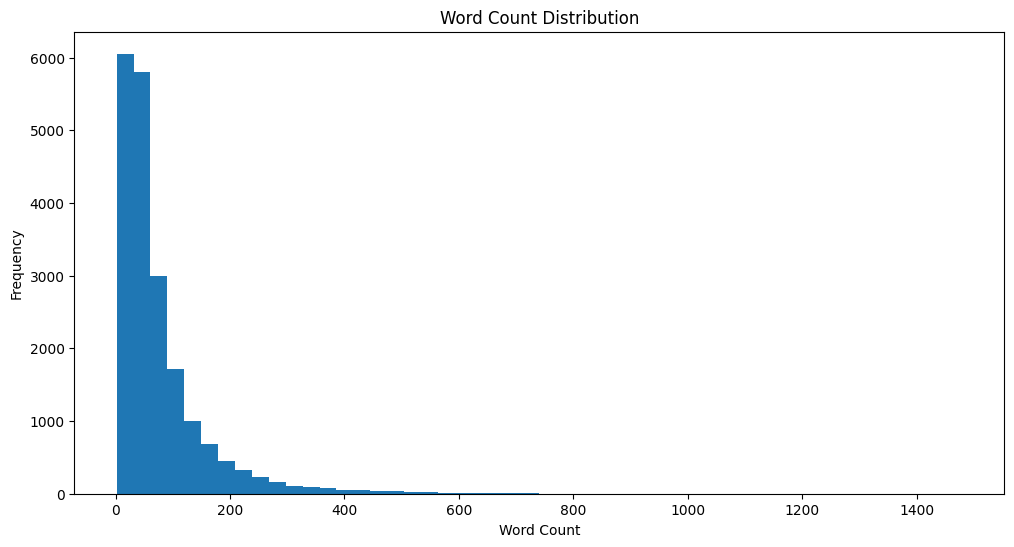


Very Short Reviews (<3 words): 2

Dataset Shape After Removing Short Reviews:
(19947, 13)

Final Dataset Preview:


,combined_text,cleaned_text,word_count
287573,The Lies of Locke Lamora Scott Lynch along wit...,lies locke lamora scott lynch along patrick ro...,92
28692,Great Expectations (Signet classics) This is m...,great expectations signet classics least favor...,74
219931,The Power of Kabbalah: Technology for the Soul...,power kabbalah technology soul ive noticed man...,164
102912,Language Teaching Awareness: A Guide to Explor...,language teaching awareness guide exploring be...,78
124804,Las Luces de Septiembre (Spanish Edition) I bo...,las luces septiembre spanish edition bought on...,73



Remaining Missing Values:


id                    0
title                 0
user_id            3895
profilename        3896
review_time           0
review_text           0
review_length         0
combined_text         0
review_datetime       0
review_year           0
cleaned_text          0
cleaned_length        0
word_count            0
dtype: int64


Cleaned Dataset Saved Successfully

Final Dataset Shape:
(19947, 13)

Final Dataset Columns:
['id', 'title', 'user_id', 'profilename', 'review_time', 'review_text', 'review_length', 'combined_text', 'review_datetime', 'review_year', 'cleaned_text', 'cleaned_length', 'word_count']

NOTEBOOK 02 COMPLETED SUCCESSFULLY

Tasks Completed:
1. Dataset Loaded
2. Dataset Sampling
3. Preprocessing Module Imported
4. Null Value Handling
5. Lowercase Conversion
6. HTML Removal
7. URL Removal
8. Special Character Removal
9. Stopword Removal
10. Tokenization
11. Empty Review Removal
12. Duplicate Removal
13. Word Count Feature
14. Cleaned Word Analysis
15. Cleaned Dataset Saved

Ready for Notebook 03 — Feature Engineering


In [1]:
# ============================================================
# AMAZON BOOK REVIEWS CLUSTERING PROJECT
# NOTEBOOK: 02_data_preprocessing.ipynb
# ============================================================

# ============================================================
# STEP 1 — IMPORT LIBRARIES
# ============================================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from tqdm import tqdm

import warnings
warnings.filterwarnings("ignore")

print("Libraries Imported Successfully")


# ============================================================
# STEP 2 — LOAD DATASET
# ============================================================

DATA_PATH = (
    "../data/processed/"
    "data_understanding_output.csv"
)

df = pd.read_csv(DATA_PATH)

print("\nDataset Loaded Successfully")

print("\nDataset Shape:")
print(df.shape)


# ============================================================
# STEP 3 — SAMPLE DATASET FOR FASTER PROCESSING
# ============================================================

# IMPORTANT:
# Using sample dataset for faster NLP processing

df = df.sample(
    20000,
    random_state=42
)

print("\nSample Dataset Shape:")
print(df.shape)


# ============================================================
# STEP 4 — IMPORT SYSTEM MODULE
# ============================================================

import sys
import os

sys.path.append(
    os.path.abspath("..")
)


# ============================================================
# STEP 5 — IMPORT PREPROCESSING FUNCTION
# ============================================================

from src.data_preprocessing import clean_text

print("\nPreprocessing Function Imported Successfully")


# ============================================================
# STEP 6 — CHECK DATASET COLUMNS
# ============================================================

print("\nDataset Columns:")

print(df.columns.tolist())


# ============================================================
# STEP 7 — HANDLE NULL VALUES
# ============================================================

text_columns = [
    "title",
    "review_text",
    "combined_text"
]

for col in text_columns:

    if col in df.columns:

        df[col] = (
            df[col]
            .fillna("")
            .astype(str)
        )

print("\nNull Values Handled Successfully")


# ============================================================
# STEP 8 — TEST CLEANING FUNCTION
# ============================================================

sample_text = df[
    "combined_text"
].iloc[0]

print("\n================ ORIGINAL TEXT ================\n")

print(sample_text)


# ============================================================
# STEP 9 — CLEAN SAMPLE TEXT
# ============================================================

cleaned_sample = clean_text(sample_text)

print("\n================ CLEANED TEXT ================\n")

print(cleaned_sample)


# ============================================================
# STEP 10 — ENABLE TQDM
# ============================================================

tqdm.pandas()

print("\nTQDM Enabled")


# ============================================================
# STEP 11 — APPLY TEXT PREPROCESSING
# ============================================================

print("\nStarting Text Cleaning Process...")

df["cleaned_text"] = (
    df["combined_text"]
    .progress_apply(clean_text)
)

print("\nText Cleaning Completed Successfully")


# ============================================================
# STEP 12 — CHECK CLEANED OUTPUT
# ============================================================

display(
    df[[
        "combined_text",
        "cleaned_text"
    ]].head()
)


# ============================================================
# STEP 13 — CHECK EMPTY CLEANED REVIEWS
# ============================================================

empty_cleaned = (
    df["cleaned_text"]
    .str.strip()
    .eq("")
    .sum()
)

print(f"\nEmpty Cleaned Reviews: {empty_cleaned}")


# ============================================================
# STEP 14 — REMOVE EMPTY CLEANED REVIEWS
# ============================================================

df = df[
    df["cleaned_text"]
    .str.strip() != ""
]

print("\nDataset Shape After Removing Empty Reviews:")

print(df.shape)


# ============================================================
# STEP 15 — CREATE CLEANED TEXT LENGTH FEATURE
# ============================================================

df["cleaned_length"] = (
    df["cleaned_text"]
    .apply(lambda x: len(str(x)))
)

print("\nCleaned Length Feature Created")


# ============================================================
# STEP 16 — CLEANED LENGTH STATISTICS
# ============================================================

print("\nCleaned Text Length Statistics:")

display(
    df["cleaned_length"].describe()
)


# ============================================================
# STEP 17 — CLEANED LENGTH HISTOGRAM
# ============================================================

plt.figure(figsize=(12,6))

plt.hist(
    df["cleaned_length"],
    bins=50
)

plt.title("Cleaned Text Length Distribution")

plt.xlabel("Cleaned Text Length")

plt.ylabel("Frequency")

plt.show()


# ============================================================
# STEP 18 — CLEANED LENGTH BOXPLOT
# ============================================================

plt.figure(figsize=(12,4))

sns.boxplot(
    x=df["cleaned_length"]
)

plt.title("Cleaned Text Length Outliers")

plt.show()


# ============================================================
# STEP 19 — CHECK DUPLICATE CLEANED REVIEWS
# ============================================================

duplicate_cleaned = (
    df["cleaned_text"]
    .duplicated()
    .sum()
)

print(f"\nDuplicate Cleaned Reviews: {duplicate_cleaned}")


# ============================================================
# STEP 20 — REMOVE DUPLICATE CLEANED REVIEWS
# ============================================================

df.drop_duplicates(
    subset=["cleaned_text"],
    inplace=True
)

print("\nDataset Shape After Removing Duplicates:")

print(df.shape)


# ============================================================
# STEP 21 — TOP CLEANED WORDS
# ============================================================

from collections import Counter

all_cleaned_words = " ".join(
    df["cleaned_text"]
).split()

cleaned_word_freq = Counter(
    all_cleaned_words
)

print("\nTop 20 Cleaned Words:")

print(
    cleaned_word_freq.most_common(20)
)


# ============================================================
# STEP 22 — CLEANED WORDS DATAFRAME
# ============================================================

common_cleaned_words = pd.DataFrame(
    cleaned_word_freq.most_common(20),
    columns=["Word", "Frequency"]
)

display(common_cleaned_words)


# ============================================================
# STEP 23 — CLEANED WORDS VISUALIZATION
# ============================================================

plt.figure(figsize=(12,6))

sns.barplot(
    x="Frequency",
    y="Word",
    data=common_cleaned_words
)

plt.title("Top 20 Cleaned Words")

plt.xlabel("Frequency")

plt.ylabel("Word")

plt.show()


# ============================================================
# STEP 24 — CREATE WORD COUNT FEATURE
# ============================================================

df["word_count"] = (
    df["cleaned_text"]
    .apply(lambda x: len(x.split()))
)

print("\nWord Count Feature Created")


# ============================================================
# STEP 25 — WORD COUNT STATISTICS
# ============================================================

print("\nWord Count Statistics:")

display(
    df["word_count"].describe()
)


# ============================================================
# STEP 26 — WORD COUNT DISTRIBUTION
# ============================================================

plt.figure(figsize=(12,6))

plt.hist(
    df["word_count"],
    bins=50
)

plt.title("Word Count Distribution")

plt.xlabel("Word Count")

plt.ylabel("Frequency")

plt.show()


# ============================================================
# STEP 27 — CHECK VERY SHORT REVIEWS
# ============================================================

short_reviews = (
    df["word_count"] < 3
).sum()

print(f"\nVery Short Reviews (<3 words): {short_reviews}")


# ============================================================
# STEP 28 — REMOVE VERY SHORT REVIEWS
# ============================================================

df = df[
    df["word_count"] >= 3
]

print("\nDataset Shape After Removing Short Reviews:")

print(df.shape)


# ============================================================
# STEP 29 — FINAL CLEANED DATASET CHECK
# ============================================================

print("\nFinal Dataset Preview:")

display(
    df[[
        "combined_text",
        "cleaned_text",
        "word_count"
    ]].head()
)


# ============================================================
# STEP 30 — FINAL NULL VALUE CHECK
# ============================================================

print("\nRemaining Missing Values:")

display(
    df.isnull().sum()
)


# ============================================================
# STEP 31 — SAVE CLEANED DATASET
# ============================================================

OUTPUT_PATH = (
    "../data/processed/"
    "cleaned_reviews.csv"
)

df.to_csv(
    OUTPUT_PATH,
    index=False
)

print("\nCleaned Dataset Saved Successfully")


# ============================================================
# STEP 32 — FINAL DATASET SHAPE
# ============================================================

print("\nFinal Dataset Shape:")

print(df.shape)


# ============================================================
# STEP 33 — FINAL COLUMN CHECK
# ============================================================

print("\nFinal Dataset Columns:")

print(df.columns.tolist())


# ============================================================
# STEP 34 — PROJECT CHECKPOINT SUMMARY
# ============================================================

print("\n================================================")
print("NOTEBOOK 02 COMPLETED SUCCESSFULLY")
print("================================================")

print("\nTasks Completed:")

print("1. Dataset Loaded")
print("2. Dataset Sampling")
print("3. Preprocessing Module Imported")
print("4. Null Value Handling")
print("5. Lowercase Conversion")
print("6. HTML Removal")
print("7. URL Removal")
print("8. Special Character Removal")
print("9. Stopword Removal")
print("10. Tokenization")
print("11. Empty Review Removal")
print("12. Duplicate Removal")
print("13. Word Count Feature")
print("14. Cleaned Word Analysis")
print("15. Cleaned Dataset Saved")

print("\nReady for Notebook 03 — Feature Engineering")